# ru-kws: learning BC-ResNet in Colab


In [41]:
from pathlib import Path
import sys, os, json, subprocess, hashlib, zipfile, tempfile, stat, csv
import torch

REPO_URL = "https://github.com/mole88/ru-kws.git"
REPO_REF = "master"
DATASET_ZIP = Path("/content/drive/MyDrive/russian_commands/russian_commands_v001_clean_manual.zip")

RUN_NAME = "bcresnet_run_003"
RUNS_ROOT = Path("/content/drive/MyDrive/russian_commands/runs")
WINDOW_SECONDS = 3.0
BASE_C = 64                   # 8/12/16/24/48/64; 64 - BC-ResNet-8
BATCH_SIZE = 64
MAX_EPOCHS = 60
LEARNING_RATE = 3e-4
REQUIRE_GPU = torch.cuda.is_available()

RUN_FINAL_TEST = True

RUN_DIR = RUNS_ROOT / RUN_NAME
os.environ["PYTHONUNBUFFERED"] = "1" # for realtime logs output
os.environ["MPLBACKEND"] = "Agg" # for stable working with graphics libs
print("Pun path:", RUN_DIR)


Pun path: /content/drive/MyDrive/russian_commands/runs/bcresnet_run_003


## 1. Connecting Google Drive


In [2]:
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


## 2. Clone project repo


In [42]:
def run(command, cwd=None):
    print("Run:", " ".join(map(str, command)), flush=True)
    with subprocess.Popen(list(map(str, command)), cwd=cwd,
                          stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                          text=True, encoding="utf-8", errors="replace", bufsize=1) as process:
        for line in process.stdout:
            print(line, end="", flush=True)
        if process.wait():
            raise RuntimeError(f"Error {process.returncode}")

def file_sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as stream:
        for chunk in iter(lambda: stream.read(8 * 1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

def extract_cached(archive, parent):
    if not archive.is_file():
        raise FileNotFoundError(f"Fix archive path: {archive}")
    digest = file_sha256(archive)
    target = parent / digest
    marker = target / ".extraction_complete"
    if marker.exists():
        print("Use unziped archive:", target)
        return target, digest
    target.mkdir(parents=True, exist_ok=True)
    root = target.resolve()
    with zipfile.ZipFile(archive) as zf:
        members = zf.infolist()
        for member in members:
            destination = (root / member.filename).resolve()
            if not destination.is_relative_to(root) or stat.S_ISLNK(member.external_attr >> 16):
                raise ValueError(f"Wrong path: {member.filename}")
        print(f"Unpacking {len(members)} files...", flush=True)
        zf.extractall(target)
    marker.write_text(digest)
    return target, digest

def find_root(parent, marker, required):
    candidates = [p.parent for p in parent.rglob(marker)
                  if "__MACOSX" not in p.parts and all((p.parent / item).exists() for item in required)]
    if len(candidates) != 1:
        raise ValueError(f"Ожидалась одна папка с {marker}, найдены: {candidates}")
    return candidates[0]

REPO = Path(tempfile.mkdtemp(prefix="ru-kws-", dir="/content"))
run(["git", "clone", "--filter=blob:none", "--no-checkout", REPO_URL, REPO])
run(["git", "fetch", "--depth", "1", "origin", REPO_REF], cwd=REPO)
run(["git", "checkout", "--detach", "FETCH_HEAD"], cwd=REPO)
revision = subprocess.check_output(["git", "rev-parse", "HEAD"], cwd=REPO, text=True).strip()
source_info = {"mode": "github", "url": REPO_URL, "requested_ref": REPO_REF, "revision": revision}
print("Project:", REPO)
print(json.dumps(source_info, ensure_ascii=False, indent=2))


Run: git clone --filter=blob:none --no-checkout https://github.com/mole88/ru-kws.git /content/ru-kws-aq63poq4
Cloning into '/content/ru-kws-aq63poq4'...
Run: git fetch --depth 1 origin master
From https://github.com/mole88/ru-kws
 * branch            master     -> FETCH_HEAD
Run: git checkout --detach FETCH_HEAD
HEAD is now at c99d395 Add standalone TFLite dataset validation CLI
Project: /content/ru-kws-aq63poq4
{
  "mode": "github",
  "url": "https://github.com/mole88/ru-kws.git",
  "requested_ref": "master",
  "revision": "c99d39552d9d077ec34920654aa7f38031694683"
}


## 3. Установка и проверка среды

Используем PyTorch/torchaudio среды Colab; эта ячейка не переустанавливает их.
Чтение WAV реализовано через SoundFile и не требует `torchcodec`.
Если проверка GPU не проходит, включите GPU и перезапустите среду.


In [43]:
run([sys.executable, "-m", "pip", "install", "numpy>=1.24", "soundfile>=0.12", "PyYAML>=6", "matplotlib>=3.6", "packaging"])
run([sys.executable, "-m", "pip", "install", "--no-deps", "-e", REPO])
probe = """
import sys, json, torch, torchaudio
from packaging.version import Version
from ru_kws.audio.frontend import LogMelFrontend
from ru_kws.models.bcresnet import BCResNets
assert Version(torch.__version__.split('+')[0]) >= Version('2.5')
assert Version(torchaudio.__version__.split('+')[0]) >= Version('2.5')
assert not REQUIRE_GPU or torch.cuda.is_available(), 'Включите GPU в настройках Colab'
device = 'cuda' if torch.cuda.is_available() else 'cpu'
with torch.inference_mode():
    x = LogMelFrontend().to(device)(torch.zeros(1, 48000, device=device))
    model = BCResNets(8, num_classes=8).to(device).eval()
    y = model(x)
assert x.shape == (1, 1, 40, 301) and y.shape == (1, 8)
print(json.dumps({'python': sys.version, 'torch': str(torch.__version__),
    'torchaudio': str(torchaudio.__version__), 'device': device,
    'gpu': torch.cuda.get_device_name(0) if torch.cuda.is_available() else None}, indent=2))
"""
run([sys.executable, "-c", "REQUIRE_GPU = " + repr(REQUIRE_GPU) + "\n" + probe])


Run: /usr/bin/python3 -m pip install numpy>=1.24 soundfile>=0.12 PyYAML>=6 matplotlib>=3.6 packaging
Run: /usr/bin/python3 -m pip install --no-deps -e /content/ru-kws-aq63poq4
Obtaining file:///content/ru-kws-aq63poq4
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Building editable for ru-kws (pyproject.toml): started
  Building editable for ru-kws (pyproject.toml): finished with status 'done'
  Created wheel for ru-kws: filename=ru_kws-0.1.0-0.editable-py3-none-any.whl size=1300 sha256=63b5db2bd63508fb02bda824400f0a04f42f6c6cf9699e65a15d49d78

## 4. Локальная копия датасета

Корень с `labels.json` находится автоматически, включая вложенную папку архива.
Повторная распаковка того же архива в одной среде пропускается.


In [5]:
unpacked, dataset_archive_hash = extract_cached(DATASET_ZIP, Path("/content/ru_kws_data"))
DATA_ROOT = find_root(unpacked, "labels.json", ["splits/train.jsonl", "splits/val.jsonl", "splits/test.jsonl"])
print("Датасет:", DATA_ROOT)
print("Метки:", json.loads((DATA_ROOT / "labels.json").read_text(encoding="utf-8")))


Unpacking 11316 files...
Датасет: /content/ru_kws_data/8213961888b37d67ceb000ca6ffdf9f5bfe330d6f68003fcd54e49f002005884/russian_commands_v001_clean_manual
Метки: {'next': 0, 'back': 1, 'repeat': 2, 'start_timer': 3, 'stop_timer': 4, 'time_left': 5, 'unknown': 6, 'background': 7}


## 5. Configuration and validation data



In [13]:
import yaml
config = yaml.safe_load((REPO / "configs/baseline.yaml").read_text(encoding="utf-8"))
config["audio"]["window_seconds"] = WINDOW_SECONDS
config["model"]["base_c"] = BASE_C
config["training"].update(batch_size=BATCH_SIZE, max_epochs=MAX_EPOCHS,
                          learning_rate=LEARNING_RATE, num_workers=0)
CONFIG_PATH = Path("/content/ru_kws_colab_config.yaml")
CONFIG_PATH.write_text(yaml.safe_dump(config, sort_keys=False), encoding="utf-8")
print(CONFIG_PATH.read_text())
run([sys.executable, "-m", "ru_kws.data.validate", "--data-root", DATA_ROOT,
     "--window-seconds", WINDOW_SECONDS], cwd=REPO)


seed: 42
audio:
  sample_rate: 16000
  window_seconds: 3.0
frontend:
  n_fft: 512
  win_length: 480
  hop_length: 160
  n_mels: 40
  power: 2.0
  center: true
  log_eps: 1.0e-06
model:
  name: bcresnet
  base_c: 64
training:
  batch_size: 64
  num_workers: 0
  max_epochs: 60
  learning_rate: 0.0003
  label_smoothing: 0.1
  early_stopping_patience: 8
  scheduler_patience: 2

Run: /usr/bin/python3 -m ru_kws.data.validate --data-root /content/ru_kws_data/8213961888b37d67ceb000ca6ffdf9f5bfe330d6f68003fcd54e49f002005884/russian_commands_v001_clean_manual --window-seconds 3.0
train: kept 6959, dropped 28 commands longer than 3.0s; by label: {'back': 7, 'time_left': 3, 'repeat': 2, 'start_timer': 8, 'stop_timer': 6, 'next': 2}
val: kept 1483, dropped 10 commands longer than 3.0s; by label: {'start_timer': 1, 'repeat': 1, 'stop_timer': 7, 'back': 1}
test: kept 1496, dropped 4 commands longer than 3.0s; by label: {'back': 1, 'start_timer': 2, 'repeat': 1}
train {'background': 700, 'next': 697, 

## 6. Learning


In [14]:
if RUN_DIR.exists() and any(RUN_DIR.iterdir()):
    raise FileExistsError(f"Run already exist: {RUN_DIR}.")
run([sys.executable, "-m", "ru_kws.train", "--config", CONFIG_PATH,
     "--data-root", DATA_ROOT, "--run-dir", RUN_DIR, "--device", "auto"], cwd=REPO)
(RUN_DIR / "colab_source.json").write_text(json.dumps({
    "source": source_info, "dataset_archive": str(DATASET_ZIP),
    "dataset_archive_sha256": dataset_archive_hash,
}, ensure_ascii=False, indent=2), encoding="utf-8")
print("Best checkpoint:", RUN_DIR / "best.pt")


Run: /usr/bin/python3 -m ru_kws.train --config /content/ru_kws_colab_config.yaml --data-root /content/ru_kws_data/8213961888b37d67ceb000ca6ffdf9f5bfe330d6f68003fcd54e49f002005884/russian_commands_v001_clean_manual --run-dir /content/drive/MyDrive/russian_commands/runs/bcresnet_run_003 --device auto
train: kept 6959, dropped 28 commands longer than 3.0s; by label: {'back': 7, 'time_left': 3, 'repeat': 2, 'start_timer': 8, 'stop_timer': 6, 'next': 2}
val: kept 1483, dropped 10 commands longer than 3.0s; by label: {'start_timer': 1, 'repeat': 1, 'stop_timer': 7, 'back': 1}
Device: cuda; parameters: 320,040
Epoch 1: train loss=1.6045; val loss=1.2224; val accuracy=0.8139 [best]
Epoch 2: train loss=1.0018; val loss=0.8031; val accuracy=0.9413 [best]
Epoch 3: train loss=0.6811; val loss=0.6483; val accuracy=0.9609 [best]
Epoch 4: train loss=0.5797; val loss=0.6057; val accuracy=0.9697 [best]
Epoch 5: train loss=0.5472; val loss=0.6275; val accuracy=0.9589
Epoch 6: train loss=0.5298; val loss

## 7. Графики обучения
Строятся из сохранённого `history.csv`, без повторного обучения.


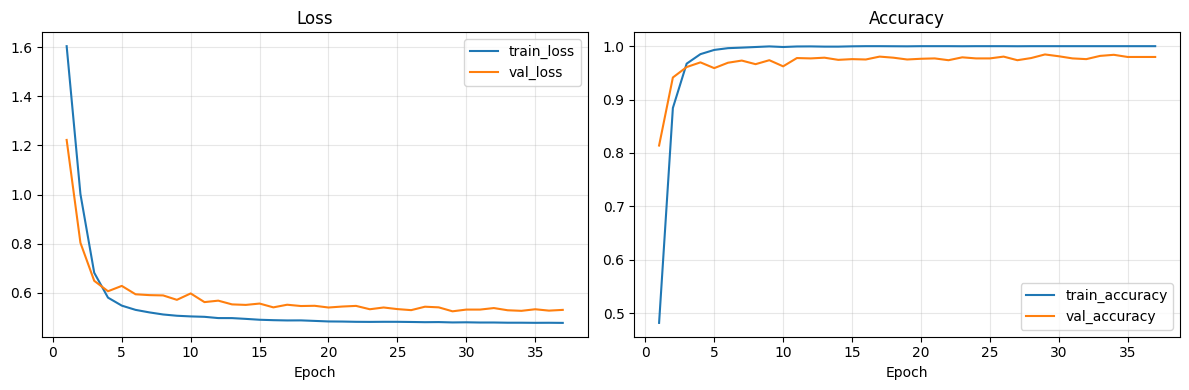

In [15]:
import matplotlib.pyplot as plt
with (RUN_DIR / "history.csv").open(encoding="utf-8") as stream:
    history = list(csv.DictReader(stream))
epochs = [int(row["epoch"]) for row in history]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for key in ("train_loss", "val_loss"):
    axes[0].plot(epochs, [float(row[key]) for row in history], label=key)
for key in ("train_accuracy", "val_accuracy"):
    axes[1].plot(epochs, [float(row[key]) for row in history], label=key)
for ax, title in zip(axes, ("Loss", "Accuracy")):
    ax.set_title(title); ax.set_xlabel("Epoch"); ax.grid(alpha=0.3); ax.legend()
fig.tight_layout()
(RUN_DIR / "reports").mkdir(exist_ok=True)
fig.savefig(RUN_DIR / "reports" / "training.png", dpi=150)
plt.show()


## 8. Оценка лучшего checkpoint на validation

CLI сам загружает `best.pt`, его frontend config и label map.
Это classification-метрики клипов, не FP/hour и не задержка потокового распознавания.


Run: /usr/bin/python3 -m ru_kws.evaluate --checkpoint /content/drive/MyDrive/russian_commands/runs/bcresnet_run_003/best.pt --data-root /content/ru_kws_data/8213961888b37d67ceb000ca6ffdf9f5bfe330d6f68003fcd54e49f002005884/russian_commands_v001_clean_manual --split val --output /content/drive/MyDrive/russian_commands/runs/bcresnet_run_003/reports/val.json
val: kept 1483, dropped 10 commands longer than 3.0s; by label: {'start_timer': 1, 'repeat': 1, 'stop_timer': 7, 'back': 1}
{
  "count": 1483,
  "accuracy": 0.9844908968307485,
  "macro_f1": 0.987424276315459,
  "per_class": {
    "next": {
      "precision": 1.0,
      "recall": 1.0,
      "f1": 1.0,
      "support": 150
    },
    "back": {
      "precision": 1.0,
      "recall": 0.993006993006993,
      "f1": 0.9964912280701755,
      "support": 143
    },
    "repeat": {
      "precision": 0.9933333333333333,
      "recall": 1.0,
      "f1": 0.9966555183946488,
      "support": 149
    },
    "start_timer": {
      "precision": 0.8

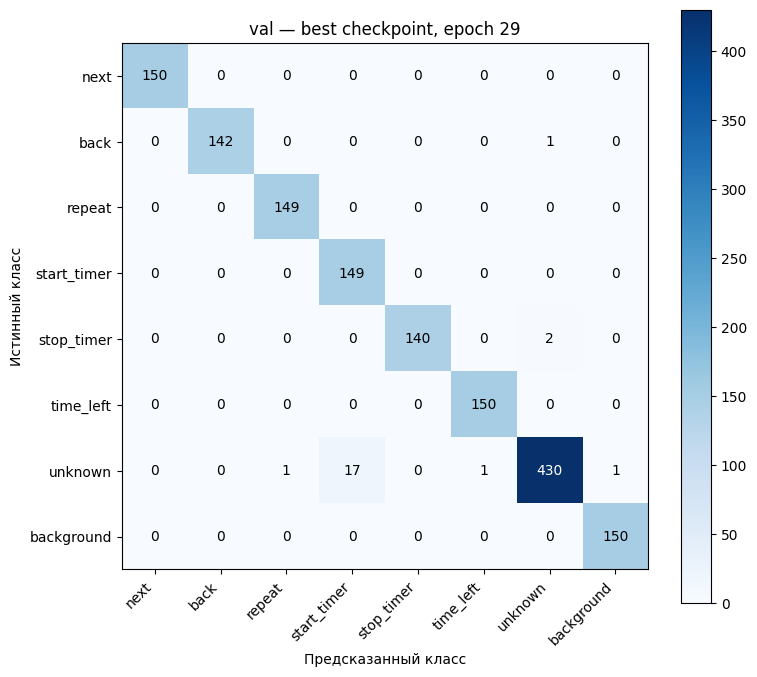

In [16]:
def evaluate_split(split):
    checkpoint = RUN_DIR / "best.pt"
    if not checkpoint.is_file():
        raise FileNotFoundError(f"Не найден checkpoint: {checkpoint}")
    output_path = RUN_DIR / "reports" / f"{split}.json"
    run([sys.executable, "-m", "ru_kws.evaluate", "--checkpoint", checkpoint,
         "--data-root", DATA_ROOT, "--split", split, "--output", output_path], cwd=REPO)
    return json.loads(output_path.read_text(encoding="utf-8"))

def show_report(report):
    import numpy as np
    print(f"Epoch: {report['epoch']} | split: {report['split']} | N={report['count']}")
    print(f"Accuracy: {report['accuracy']:.4f} | macro F1: {report['macro_f1']:.4f}")
    print(f"{'Class':20s} {'Precision':>10s} {'Recall':>10s} {'F1':>10s} {'Support':>8s}")
    for name in report["class_order"]:
        row = report["per_class"][name]
        print(f"{name:20s} {row['precision']:10.4f} {row['recall']:10.4f} {row['f1']:10.4f} {row['support']:8d}")
    cm = np.array(report["confusion_matrix"])
    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(cm, cmap="Blues")
    names = report["class_order"]
    ax.set_xticks(range(len(names)), names, rotation=45, ha="right")
    ax.set_yticks(range(len(names)), names)
    for (i, j), value in np.ndenumerate(cm):
        ax.text(j, i, str(value), ha="center", va="center",
                color="white" if value > cm.max() / 2 else "black")
    ax.set_xlabel("Предсказанный класс"); ax.set_ylabel("Истинный класс")
    ax.set_title(f"{report['split']} — best checkpoint, epoch {report['epoch']}")
    fig.colorbar(im, ax=ax); fig.tight_layout()
    fig.savefig(RUN_DIR / "reports" / f"{report['split']}_confusion.png", dpi=150)
    plt.show()

val_report = evaluate_split("val")
show_report(val_report)


## 9. Финальный test — опционально

После фиксации модели и настроек поставьте `RUN_FINAL_TEST=True` в настройках
или непосредственно перед условием ниже. По умолчанию при «Выполнить все» test не запускается.


Run: /usr/bin/python3 -m ru_kws.evaluate --checkpoint /content/drive/MyDrive/russian_commands/runs/bcresnet_run_003/best.pt --data-root /content/ru_kws_data/8213961888b37d67ceb000ca6ffdf9f5bfe330d6f68003fcd54e49f002005884/russian_commands_v001_clean_manual --split test --output /content/drive/MyDrive/russian_commands/runs/bcresnet_run_003/reports/test.json
test: kept 1496, dropped 4 commands longer than 3.0s; by label: {'back': 1, 'start_timer': 2, 'repeat': 1}
{
  "count": 1496,
  "accuracy": 0.9505347593582888,
  "macro_f1": 0.9587529927558907,
  "per_class": {
    "next": {
      "precision": 1.0,
      "recall": 1.0,
      "f1": 1.0,
      "support": 150
    },
    "back": {
      "precision": 1.0,
      "recall": 0.9932885906040269,
      "f1": 0.9966329966329966,
      "support": 149
    },
    "repeat": {
      "precision": 0.9933333333333333,
      "recall": 1.0,
      "f1": 0.9966555183946488,
      "support": 149
    },
    "start_timer": {
      "precision": 0.99242424242424

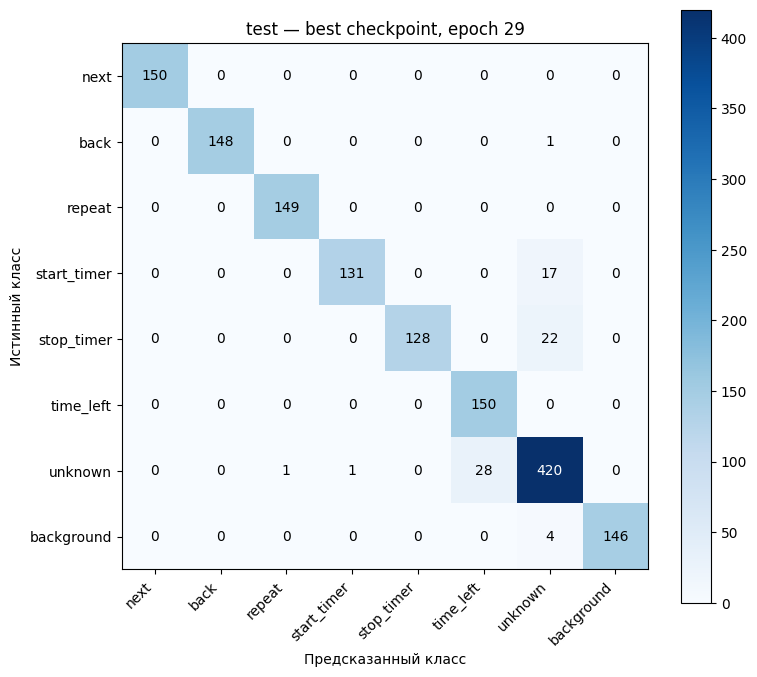

Все результаты на Drive: /content/drive/MyDrive/russian_commands/runs/bcresnet_run_003


In [17]:
if RUN_FINAL_TEST:
    test_report = evaluate_split("test")
    show_report(test_report)
else:
    print("Test пропущен.")
print("Все результаты на Drive:", RUN_DIR)


In [20]:
import sys
import subprocess
from pathlib import Path

REPO = Path("/content/bcresnet")

if not REPO.exists():
    subprocess.run(
        ["git", "clone",
         "https://github.com/Qualcomm-AI-research/bcresnet.git",
         str(REPO)],
        check=True,
    )

if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

from bcresnet import BCResNets

In [21]:

CHECKPOINT_PATH = Path(
    "/content/drive/MyDrive/russian_commands/runs/bcresnet_run_003/best.pt"
)

if not CHECKPOINT_PATH.is_file():
    raise FileNotFoundError(CHECKPOINT_PATH)

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=True,
)

model = BCResNets(
    base_c=64,       # Как при обучении
    num_classes=8,
)

if "model_state_dict" in checkpoint:
    state_dict = checkpoint["model_state_dict"]
    print("Эпоха:", checkpoint.get("epoch", "не сохранена"))
    print("Лучший val loss:", checkpoint.get("best_val_loss", "не сохранён"))
else:
    state_dict = checkpoint

model.load_state_dict(state_dict, strict=True)
model = model.cpu().float().eval()

print("Веса модели загружены")

Эпоха: 29
Лучший val loss: 0.5239773461003603
Веса модели загружены


In [27]:
SRC = Path("/content/ru-kws-d1_ol197/src")
sys.path.insert(0, str(SRC))

from ru_kws.audio.frontend import LogMelFrontend

frontend = LogMelFrontend(16_000).cpu().float().eval()

In [28]:
SAMPLE_RATE = 16_000
WINDOW_SECONDS = 3.0

waveforms = torch.randn(
    1, int(SAMPLE_RATE * WINDOW_SECONDS),
    dtype=torch.float32,
) * 0.01

with torch.inference_mode():
    features = frontend(waveforms)
    logits = model(features)

print("Аудио:", tuple(waveforms.shape))  # (1, 48000)
print("Log-mel:", tuple(features.shape)) # (1, 1, 40, 301)
print("Логиты:", tuple(logits.shape))    # (1, 8)

assert logits.shape == (1, 8)
assert torch.isfinite(features).all()
assert torch.isfinite(logits).all()

Аудио: (1, 48000)
Log-mel: (1, 1, 40, 301)
Логиты: (1, 8)


In [31]:
!pip install litert-torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 807.3/807.3 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 459.5/459.5 kB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.3/21.3 MB 84.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.8/69.8 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 59.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 109.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 25.7 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0
  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.16.0
    Uninstalling typing_ext

In [32]:
import copy
import torch
from torch import nn
import litert_torch


class AudioCommandModel(nn.Module):
    def __init__(self, frontend, classifier):
        super().__init__()
        self.frontend = frontend
        self.classifier = classifier

    def forward(self, waveforms):
        features = self.frontend(waveforms)
        return self.classifier(features)

export_model = AudioCommandModel(
    frontend=copy.deepcopy(frontend),
    classifier=copy.deepcopy(model),
).cpu().float().eval()

example_audio = torch.randn(1, 48_000, dtype=torch.float32) * 0.01

with torch.inference_mode():
    logits = export_model(example_audio)

assert logits.shape == (1, 8)

# Проверка возможности экспорта именно вашего frontend.
edge_model = litert_torch.convert(
    export_model,
    (example_audio,),
)

edge_model.export("/content/bcresnet_with_frontend_fp32.tflite")

(00:00) [START] LiteRT-Torch Convert

(00:00) [START] LiteRT-Torch Convert > Torch Export: serving_default

(00:03) [START] LiteRT-Torch Convert > Torch Export: serving_default > ExportedProgram Run Decompositions

/usr/lib/python3.13/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


(00:05) [ DONE] LiteRT-Torch Convert > Torch Export: serving_default > ExportedProgram Run Decompositions (+00:02)

...

(00:13) [START] LiteRT-Torch Convert > Lower to MLIR: serving_default > Create MLIR Module

(00:15) [ FAIL] LiteRT-Torch Convert > Lower to MLIR: serving_default > Create MLIR Module

(00:15) [ FAIL] LiteRT-Torch Convert > Lower to MLIR: serving_default

(00:15) [ FAIL] LiteRT-Torch Convert

RuntimeError: Unsupported ir element type: complex<f32>

While executing %permute : [num_users=1] = call_function[target=torch.ops.aten.permute.default](args = (%_fft_r2c, [0, 2, 1]), kwargs = {})
Original traceback:
File "/tmp/ipykernel_516/1059097416.py", line 14, in forward
    features = self.frontend(waveforms)
  File "/content/ru-kws-d1_ol197/src/ru_kws/audio/frontend.py", line 19, in forward
    return torch.log(self.mel(waveforms) + self.log_eps).unsqueeze(1)
  File "/usr/local/lib/python3.13/dist-packages/torchaudio/transforms/_transforms.py", line 629, in forward
    specgram = self.spectrogram(waveform)
  File "/usr/local/lib/python3.13/dist-packages/torchaudio/transforms/_transforms.py", line 111, in forward
    return F.spectrogram(
Use tlparse to see full graph. (https://github.com/pytorch/tlparse?tab=readme-ov-file#tlparse-parse-structured-pt2-logs)

In [33]:
import copy
import torch
import torch.nn.functional as F
from torch import nn


class ExportableLogMelFrontend(nn.Module):
    def __init__(self, source_frontend):
        super().__init__()

        mel = source_frontend.mel
        spec = mel.spectrogram

        # Эта реализация рассчитана на настройки вашего обучения.
        assert spec.power == 2.0
        assert spec.normalized is False
        assert spec.onesided is True
        assert spec.center is True
        assert spec.pad_mode == "reflect"
        assert spec.pad == 0

        self.n_fft = spec.n_fft
        self.hop_length = spec.hop_length
        self.n_freqs = self.n_fft // 2 + 1
        self.log_eps = float(getattr(source_frontend, "log_eps", 1e-6))

        # Считаем константы в float64, затем сохраняем в float32.
        window = spec.window.detach().cpu().double()
        missing = self.n_fft - window.numel()
        window = F.pad(
            window,
            (missing // 2, missing - missing // 2),
        )

        frequencies = torch.arange(self.n_freqs, dtype=torch.float64)
        samples = torch.arange(self.n_fft, dtype=torch.float64)
        angles = (
            2 * torch.pi
            * frequencies[:, None]
            * samples[None, :]
            / self.n_fft
        )

        real_filters = torch.cos(angles) * window
        imag_filters = -torch.sin(angles) * window

        filters = torch.cat(
            [real_filters, imag_filters], dim=0
        ).unsqueeze(1).float()

        self.register_buffer("dft_filters", filters)

        # [частоты, mel] → [mel, частоты, 1]
        mel_filters = (
            mel.mel_scale.fb.detach().cpu().float()
            .T.contiguous().unsqueeze(-1)
        )
        self.register_buffer("mel_filters", mel_filters)

    def forward(self, waveforms):
        x = waveforms.unsqueeze(1)  # [B, 1, N]
        x = F.pad(
            x,
            (self.n_fft // 2, self.n_fft // 2),
            mode="reflect",
        )

        spectrum = F.conv1d(
            x, self.dft_filters, stride=self.hop_length
        )
        real = spectrum[:, :self.n_freqs, :]
        imag = spectrum[:, self.n_freqs:, :]

        power = real.square() + imag.square()
        mel = F.conv1d(power, self.mel_filters)

        return torch.log(mel + self.log_eps).unsqueeze(1)


reference_frontend = copy.deepcopy(frontend).cpu().float().eval()
export_frontend = ExportableLogMelFrontend(reference_frontend).eval()

In [35]:
import litert_torch


class AudioCommandModel(nn.Module):
    def __init__(self, frontend, classifier):
        super().__init__()
        self.frontend = frontend
        self.classifier = classifier

    def forward(self, waveforms):
        return self.classifier(self.frontend(waveforms))


export_model = AudioCommandModel(
    export_frontend,
    copy.deepcopy(model).cpu().float().eval(),
).eval()

example_audio = checks["шум"]

edge_model = litert_torch.convert(
    export_model,
    (example_audio,),
)

TFLITE_PATH = "/content/bcresnet_with_frontend_fp32.tflite"
edge_model.export(TFLITE_PATH)

print("Сохранено:", TFLITE_PATH)

(00:00) [START] LiteRT-Torch Convert

(00:00) [START] LiteRT-Torch Convert > Torch Export: serving_default

(00:01) [START] LiteRT-Torch Convert > Torch Export: serving_default > ExportedProgram Run Decompositions

/usr/lib/python3.13/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


(00:05) [ DONE] LiteRT-Torch Convert > Torch Export: serving_default > ExportedProgram Run Decompositions (+00:04)

...

(00:17) [ DONE] LiteRT-Torch Convert > Run LiteRT Converter Passes (+00:00)

(00:17) [ DONE] LiteRT-Torch Convert (+00:17)

(00:00) [START] Write Model to /content/bcresnet_with_frontend_fp32.tflite

(00:00) [ DONE] Write Model to /content/bcresnet_with_frontend_fp32.tflite (+00:00)

Сохранено: /content/bcresnet_with_frontend_fp32.tflite


In [36]:
import numpy as np
from ai_edge_litert.interpreter import Interpreter

interpreter = Interpreter(model_path=TFLITE_PATH)
interpreter.allocate_tensors()

input_info = interpreter.get_input_details()[0]
output_info = interpreter.get_output_details()[0]

assert tuple(input_info["shape"]) == (1, 48_000)
assert input_info["dtype"] == np.float32

classifier = export_model.classifier

with torch.inference_mode():
    for name, batch in checks.items():
        for i in range(len(batch)):
            audio = batch[i:i + 1].contiguous()

            # Сравниваем с исходным frontend из обучения.
            expected = classifier(reference_frontend(audio)).numpy()

            interpreter.set_tensor(
                input_info["index"], audio.numpy()
            )
            interpreter.invoke()
            actual = interpreter.get_tensor(output_info["index"])

            error = np.max(np.abs(expected - actual))
            print(f"{name}[{i}]: max logit diff={error:.6g}")

            np.testing.assert_allclose(
                actual, expected,
                atol=1e-3,
                rtol=1e-3,
            )

print("Проверка TFLite пройдена")

тишина[0]: max logit diff=2.02656e-06
шум[0]: max logit diff=9.53674e-07
Проверка TFLite пройдена


In [46]:
!python /content/ru-kws-aq63poq4/scripts/evaluate_tflite.py \
    --model /content/bcresnet_with_frontend_fp32.tflite \
    --dataset-root /content/ru_kws_data/8213961888b37d67ceb000ca6ffdf9f5bfe330d6f68003fcd54e49f002005884/russian_commands_v001_clean_manual \
    --split val \
    --window-seconds 3 \
    --long-commands skip \
    --label-smoothing 0.1 \
    --output-dir /content/evaluation/bcresnet_val_001

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
Input: [    1 48000] <class 'numpy.float32'>
Output: [1 8] <class 'numpy.float32'>
TFLite validation: 100% 1493/1493 [00:38<00:00, 39.23it/s]

Evaluated: 1483/1493; processing: {'padded': 1463, 'cropped': 20, 'skipped_long': 10}
Loss: 0.523977; Accuracy: 0.984491
              precision    recall  f1-score   support

        next     1.0000    1.0000    1.0000       150
        back     1.0000    0.9930    0.9965       143
      repeat     0.9933    1.0000    0.9967       149
 start_timer     0.8976    1.0000    0.9460       149
  stop_timer     1.0000    0.9859    0.9929       142
   time_left     0.9934    1.0000    0.9967       150
     unknown     0.9931    0.9556    0.9740       450
  background     0.9934    1.0000    0.9967       150

    accuracy                         0.9845      1483
   macro avg     0.9838    0.9918    0.9874      1483
weighted avg     0.9856    0.9845    0.9846      1483

Results: /content/evaluation/